# 9 WorkFlow Analista Jr

### 9.1 Objetivo

Presentar un workflow/pipeline completo al que los estudiantes deberán
<br>El Analista Jr corre sus scripts en la virtual manchine **desktop-jr** que tiene estas características


*   Normal, paga tarifa completa, nunca es apagada por Google
*   reside en el datacenter de Toronto, Canada
*   64 GB de memoria RAM
*   8 vCPU


En Analista Jr **no** puede utilizar Google Colab porque los 12 GB de dichas maquinas virtuales no son suficientes para el tamaño del dataset que está utilizando.



## 9.3  Workflow

## Inicializacion

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [1]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Tue Sep 15 12:26:32 2026"

In [2]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,671197,35.9,1479485,79.1,1479485,79.1
Vcells,1242599,9.5,8388608,64.0,1978697,15.1


In [3]:
require("data.table")

if( !require("R.utils")) install.packages("R.utils")
require("R.utils")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, u

#### Parametros

In [4]:
PARAM <- list()
PARAM$semilla_primigenia <- 140009

PARAM$experimento <- 9190
PARAM$dataset <- "analistajr_competencia_2026.csv.gz"

#### Carpeta del Experimento

In [5]:
# carpeta de trabajo

setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("WF", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

### 9.3.1   Preprocesamiento del dataset

#### 9.3.1.1  DT incorporar dataset

In [6]:
# lectura del dataset
dataset <- fread(paste0("/content/datasets/", PARAM$dataset))

#### 9.3.1.2  CA  Catastrophe Analysis
Se intentan reparar las variables que para un mes están con todos los valores en cero.

El método que se utiliza es **Machine Learning** se asigna NA also valores, si ha leido bien, es la "anti imputación de valores faltantes"
<br> Usted podrá aplicar aquí otros métodos

In [7]:
if( !require("mice")) install.packages("mice", repos = "http://cran.us.r-project.org")
require("mice")

Loading required package: mice


Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind




In [8]:
# Escrito por alumnos de  Universidad Austral  Rosario

Corregir_MICE <- function(pcampo, pmeses) {

  meth <- rep("", ncol(dataset))
  names(meth) <- colnames(dataset)
  meth[names(meth) == pcampo] <- "sample"

  # llamada a mice  !
  imputacion <- mice(dataset,
    method = meth,
    maxit = 5,
    m = 1,
    seed = 7)

  tbl <- mice::complete(dataset)

  dataset[, paste0(pcampo) := ifelse(foto_mes %in% pmeses, tbl[, get(pcampo)], get(pcampo))]

}


In [9]:
Corregir_interpolar <- function(pcampo, pmeses) {

  tbl <- dataset[, list(
    "v1" = shift(get(pcampo), 1, type = "lag"),
    "v2" = shift(get(pcampo), 1, type = "lead")
  ),
  by = eval(envg$PARAM$dataset_metadata$entity_id)
  ]

  tbl[, paste0(envg$PARAM$dataset_metadata$entity_id) := NULL]
  tbl[, promedio := rowMeans(tbl, na.rm = TRUE)]

  dataset[
    ,
    paste0(pcampo) := ifelse(!(foto_mes %in% pmeses),
      get(pcampo),
      tbl$promedio
    )
  ]
}

In [10]:
AsignarNA_campomeses <- function(pcampo, pmeses) {

  if( pcampo %in% colnames( dataset ) ) {

    dataset[ foto_mes %in% pmeses, paste0(pcampo) := NA ]
  }
}

In [11]:

Corregir_atributo <- function(pcampo, pmeses, pmetodo)
{
  # si el campo no existe en el dataset, Afuera !
  if( !(pcampo %in% colnames( dataset )) )
    return( 1 )

  # llamo a la funcion especializada que corresponde
  switch( pmetodo,
    "MachineLearning"     = AsignarNA_campomeses(pcampo, pmeses),
    "EstadisticaClasica"  = Corregir_interpolar(pcampo, pmeses),
    "MICE"                = Corregir_MICE(pcampo, pmeses),
  )

  return( 0 )
}

In [12]:

Corregir_Rotas <- function(dataset, pmetodo) {
  gc(verbose= FALSE)
  cat( "inicio Corregir_Rotas()\n")
  # acomodo los errores del dataset

  Corregir_atributo("active_quarter", c(202006), pmetodo) # 1
  Corregir_atributo("internet", c(202006), pmetodo) # 2

  Corregir_atributo("mrentabilidad", c(201905, 201910, 202006), pmetodo) # 3
  Corregir_atributo("mrentabilidad_annual", c(201905, 201910, 202006), pmetodo) # 4

  Corregir_atributo("mcomisiones", c(201905, 201910, 202006), pmetodo) # 5

  Corregir_atributo("mactivos_margen", c(201905, 201910, 202006), pmetodo) # 6
  Corregir_atributo("mpasivos_margen", c(201905, 201910, 202006), pmetodo) # 7

  Corregir_atributo("mcuentas_saldo", c(202006), pmetodo) # 8

  Corregir_atributo("ctarjeta_debito_transacciones", c(202006), pmetodo) # 9

  Corregir_atributo("mautoservicio", c(202006), pmetodo) # 10

  Corregir_atributo("ctarjeta_visa_transacciones", c(202006), pmetodo) # 11
  Corregir_atributo("mtarjeta_visa_consumo", c(202006), pmetodo) # 12

  Corregir_atributo("ctarjeta_master_transacciones", c(202006), pmetodo) # 13
  Corregir_atributo("mtarjeta_master_consumo", c(202006), pmetodo) # 14

  Corregir_atributo("ctarjeta_visa_debitos_automaticos", c(201904), pmetodo) # 15
  Corregir_atributo("mttarjeta_visa_debitos_automaticos", c(201904), pmetodo) # 16

  Corregir_atributo("ccajeros_propios_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 17

  Corregir_atributo("mcajeros_propios_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 18

  Corregir_atributo("ctarjeta_visa_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 19

  Corregir_atributo("mtarjeta_visa_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 20

  Corregir_atributo("ctarjeta_master_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 21

  Corregir_atributo("mtarjeta_master_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 22

  Corregir_atributo("ccomisiones_otras", c(201905, 201910, 202006), pmetodo) # 23
  Corregir_atributo("mcomisiones_otras", c(201905, 201910, 202006), pmetodo) # 24

  Corregir_atributo("cextraccion_autoservicio", c(202006), pmetodo) # 25
  Corregir_atributo("mextraccion_autoservicio", c(202006), pmetodo) # 26

  Corregir_atributo("ccheques_depositados", c(202006), pmetodo) # 27
  Corregir_atributo("mcheques_depositados", c(202006), pmetodo) # 28
  Corregir_atributo("ccheques_emitidos", c(202006), pmetodo) # 29
  Corregir_atributo("mcheques_emitidos", c(202006), pmetodo) # 30
  Corregir_atributo("ccheques_depositados_rechazados", c(202006), pmetodo) # 31
  Corregir_atributo("mcheques_depositados_rechazados", c(202006), pmetodo) # 32
  Corregir_atributo("ccheques_emitidos_rechazados", c(202006), pmetodo) # 33
  Corregir_atributo("mcheques_emitidos_rechazados", c(202006), pmetodo) # 34

  Corregir_atributo("tcallcenter", c(202006), pmetodo) # 35
  Corregir_atributo("ccallcenter_transacciones", c(202006), pmetodo) # 36

  Corregir_atributo("thomebanking", c(202006), pmetodo) # 37
  Corregir_atributo("chomebanking_transacciones", c(201910, 202006), pmetodo) # 38

  Corregir_atributo("ccajas_transacciones", c(202006), pmetodo) # 39
  Corregir_atributo("ccajas_consultas", c(202006), pmetodo) # 40

  Corregir_atributo("ccajas_depositos", c(202006, 202105), pmetodo) # 41

  Corregir_atributo("ccajas_extracciones", c(202006), pmetodo) # 41
  Corregir_atributo("ccajas_otras", c(202006), pmetodo) # 43

  Corregir_atributo("catm_trx", c(202006), pmetodo) # 44
  Corregir_atributo("matm", c(202006), pmetodo) # 45
  Corregir_atributo("catm_trx_other", c(202006), pmetodo) # 46
  Corregir_atributo("matm_other", c(202006), pmetodo) # 47

  cat( "fin Corregir_rotas()\n")
}


In [13]:
# resuelvo el Catastrophe Analysis

setorder( dataset, numero_de_cliente, foto_mes )

PARAM$CA$metodo= "MachineLearning"

if( PARAM$CA$metodo %in% c("MachineLearning", "EstadisticaClasica", "MICE") )
  Corregir_Rotas(dataset, PARAM$CA$metodo)

inicio Corregir_Rotas()
fin Corregir_rotas()


#### 9.3.1.3  DR  Data Drifting
Se intenta corregir el data drifting, ajustando por algunos indices financieros

In [14]:
# meses que me interesan para el ajuste de variables monetarias
vfoto_mes <- c(
  201901, 201902, 201903, 201904, 201905, 201906,
  201907, 201908, 201909, 201910, 201911, 201912,
  202001, 202002, 202003, 202004, 202005, 202006,
  202007, 202008, 202009, 202010, 202011, 202012,
  202101, 202102, 202103, 202104, 202105, 202106,
  202107, 202108, 202109
)


In [15]:
# los valores que siguen fueron calculados por alumnos

# momento 1.0  31-dic-2020 a las 23:59
vIPC <- c(
  1.9903030878, 1.9174403544, 1.8296186587,
  1.7728862972, 1.7212488323, 1.6776304408,
  1.6431248196, 1.5814483345, 1.4947526791,
  1.4484037589, 1.3913580777, 1.3404220402,
  1.3154288912, 1.2921698342, 1.2472681797,
  1.2300475145, 1.2118694724, 1.1881073259,
  1.1693969743, 1.1375456949, 1.1065619600,
  1.0681100000, 1.0370000000, 1.0000000000,
  0.9680542110, 0.9344152616, 0.8882274350,
  0.8532444140, 0.8251880213, 0.8003763543,
  0.7763107219, 0.7566381305, 0.7289384687
)

vdolar_blue <- c(
   39.045455,  38.402500,  41.639474,
   44.274737,  46.095455,  45.063333,
   43.983333,  54.842857,  61.059524,
   65.545455,  66.750000,  72.368421,
   77.477273,  78.191667,  82.434211,
  101.087500, 126.236842, 125.857143,
  130.782609, 133.400000, 137.954545,
  170.619048, 160.400000, 153.052632,
  157.900000, 149.380952, 143.615385,
  146.250000, 153.550000, 162.000000,
  178.478261, 180.878788, 184.357143
)

vdolar_oficial <- c(
   38.430000,  39.428000,  42.542105,
   44.354211,  46.088636,  44.955000,
   43.751429,  54.650476,  58.790000,
   61.403182,  63.012632,  63.011579,
   62.983636,  63.580556,  65.200000,
   67.872000,  70.047895,  72.520952,
   75.324286,  77.488500,  79.430909,
   83.134762,  85.484737,  88.181667,
   91.474000,  93.997778,  96.635909,
   98.526000,  99.613158, 100.619048,
  101.619048, 102.569048, 103.781818
)

vUVA <- c(
  2.001408838932958,  1.950325472789153,  1.89323032351521,
  1.8247220405493787, 1.746027787673673,  1.6871348409529485,
  1.6361678865622313, 1.5927529755859773, 1.5549162794128493,
  1.4949100586391746, 1.4197729500774545, 1.3678188186372326,
  1.3136508617223726, 1.2690535173062818, 1.2381595983200178,
  1.211656735577568,  1.1770808941405335, 1.1570338657445522,
  1.1388769475653255, 1.1156993751209352, 1.093638313080772,
  1.0657171590878205, 1.0362173587708712, 1.0,
  0.9669867858358365, 0.9323750098728378, 0.8958202912590305,
  0.8631993702994263, 0.8253893405524657, 0.7928918905364516,
  0.7666323845128089, 0.7428976357662823, 0.721615762047849
)


In [16]:
tb_indices <- as.data.table( list(
  "IPC" = vIPC,
  "dolar_blue" = vdolar_blue,
  "dolar_oficial" = vdolar_oficial,
  "UVA" = vUVA
  )
)

tb_indices[[ 'foto_mes' ]] <- vfoto_mes

tb_indices

IPC,dolar_blue,dolar_oficial,UVA,foto_mes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.9903031,39.04545,38.43000,2.0014088,201901
1.9174404,38.40250,39.42800,1.9503255,201902
1.8296187,41.63947,42.54210,1.8932303,201903
1.7728863,44.27474,44.35421,1.8247220,201904
1.7212488,46.09546,46.08864,1.7460278,201905
1.6776304,45.06333,44.95500,1.6871348,201906
1.6431248,43.98333,43.75143,1.6361679,201907
1.5814483,54.84286,54.65048,1.5927530,201908
1.4947527,61.05952,58.79000,1.5549163,201909


In [17]:
drift_UVA <- function(campos_monetarios) {
  cat( "inicio drift_UVA()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD * i.UVA,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_UVA()\n")
}


In [18]:
drift_dolar_oficial <- function(campos_monetarios) {
  cat( "inicio drift_dolar_oficial()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD / i.dolar_oficial,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_dolar_oficial()\n")
}


In [19]:
drift_dolar_blue <- function(campos_monetarios) {
  cat( "inicio drift_dolar_blue()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD / i.dolar_blue,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_dolar_blue()\n")
}


In [20]:
drift_deflacion <- function(campos_monetarios) {
  cat( "inicio drift_deflacion()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD * i.IPC,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_deflacion()\n")
}


In [21]:
drift_rank_simple <- function(campos_drift) {

  cat( "inicio drift_rank_simple()\n")
  for (campo in campos_drift)
  {
    cat(campo, " ")
    dataset[, paste0(campo, "_rank") :=
      (frank(get(campo), ties.method = "random") - 1) / (.N - 1), by = list(foto_mes)]
    dataset[, (campo) := NULL]
  }
  cat( "fin drift_rank_simple()\n")
}


In [22]:
# El cero se transforma en cero
# los positivos se rankean por su lado
# los negativos se rankean por su lado

drift_rank_cero_fijo <- function(campos_drift) {

  cat( "inicio drift_rank_cero_fijo()\n")
  for (campo in campos_drift)
  {
    cat(campo, " ")
    dataset[get(campo) == 0, paste0(campo, "_rank") := 0]
    dataset[get(campo) > 0, paste0(campo, "_rank") :=
      frank(get(campo), ties.method = "random") / .N, by = list(foto_mes)]

    dataset[get(campo) < 0, paste0(campo, "_rank") :=
      -frank(-get(campo), ties.method = "random") / .N, by = list(foto_mes)]
    dataset[, (campo) := NULL]
  }
  cat("\n")
  cat( "fin drift_rank_cero_fijo()\n")
}


In [23]:
drift_estandarizar <- function(campos_drift) {

  cat( "inicio drift_estandarizar()\n")
  for (campo in campos_drift)
  {
    cat(campo, " ")
    dataset[, paste0(campo, "_normal") :=
      (get(campo) -mean(campo, na.rm=TRUE)) / sd(get(campo), na.rm=TRUE),
      by = list(foto_mes)]

    dataset[, (campo) := NULL]
  }
  cat( "fin drift_estandarizar()\n")
}


In [24]:
# por como armé los nombres de campos,
#  estos son los campos que expresan variables monetarias
campos_monetarios <- colnames(dataset)
campos_monetarios <- campos_monetarios[campos_monetarios %like%
  "^(m|Visa_m|Master_m|vm_m)"]

campos_monetarios

[1] "mrentabilidad"                      "mrentabilidad_annual"              
 [3] "mcomisiones"                        "mactivos_margen"                   
 [5] "mpasivos_margen"                    "mcuenta_corriente"                 
 [7] "mcaja_ahorro"                       "mcuentas_saldo"                    
 [9] "mtarjeta_visa_consumo"              "mtarjeta_master_consumo"           
[11] "mprestamos_personales"              "mpayroll"                          
[13] "mttarjeta_visa_debitos_automaticos" "mcomisiones_mantenimiento"         
[15] "mtransferencias_recibidas"          "Master_mfinanciacion_limite"       
[17] "Master_msaldototal"                 "Master_mlimitecompra"              
[19] "Master_mconsumototal"               "Master_mpagominimo"                
[21] "Visa_mfinanciacion_limite"          "Visa_msaldototal"                  
[23] "Visa_mlimitecompra"                 "Visa_mconsumototal"                
[25] "Visa_mpagominimo"

In [25]:
# ejecuto el Data Drifting
setorder( dataset, numero_de_cliente, foto_mes )


PARAM$DR$metodo <- "deflacion"

switch(PARAM$DR$metodo,
  "ninguno"        = cat("No hay correccion del data drifting"),
  "rank_simple"    = drift_rank_simple(campos_monetarios),
  "rank_cero_fijo" = drift_rank_cero_fijo(campos_monetarios),
  "deflacion"      = drift_deflacion(campos_monetarios),
  "dolar_blue"     = drift_dolarblue(campos_monetarios),
  "dolar_oficial"  = drift_dolaroficial(campos_monetarios),
  "UVA"            = drift_UVA(campos_monetarios),
  "estandarizar"   = drift_estandarizar(campos_monetarios)
)


inicio drift_deflacion()
fin drift_deflacion()


In [26]:
colnames(dataset)

[1] "numero_de_cliente"                  "foto_mes"                          
 [3] "internet"                           "cliente_edad"                      
 [5] "cliente_antiguedad"                 "mrentabilidad"                     
 [7] "mrentabilidad_annual"               "mcomisiones"                       
 [9] "mactivos_margen"                    "mpasivos_margen"                   
[11] "cproductos"                         "mcuenta_corriente"                 
[13] "mcaja_ahorro"                       "cdescubierto_preacordado"          
[15] "mcuentas_saldo"                     "ctarjeta_visa"                     
[17] "ctarjeta_visa_transacciones"        "mtarjeta_visa_consumo"             
[19] "ctarjeta_master"                    "ctarjeta_master_transacciones"     
[21] "mtarjeta_master_consumo"            "cprestamos_personales"             
[23] "mprestamos_personales"              "cpayroll_trx"                      
[25] "mpayroll"                           "mttarjeta_visa_debitos_automaticos"
[27] "ccomisiones_mantenimiento"          "mcomisiones_mantenimiento"         
[29] "ccomisiones_otras"                  "mtransferencias_recibidas"         
[31] "ccallcenter_transacciones"          "thomebanking"                      
[33] "chomebanking_transacciones"         "ctrx_quarter"                      
[35] "Master_status"                      "Master_mfinanciacion_limite"       
[37] "Master_Fvencimiento"                "Master_msaldototal"                
[39] "Master_mlimitecompra"               "Master_fultimo_cierre"             
[41] "Master_fechaalta"                   "Master_mconsumototal"              
[43] "Master_cconsumos"                   "Master_mpagominimo"                
[45] "Visa_status"                        "Visa_mfinanciacion_limite"         
[47] "Visa_Fvencimiento"                  "Visa_msaldototal"                  
[49] "Visa_mlimitecompra"                 "Visa_fultimo_cierre"               
[51] "Visa_fechaalta"                     "Visa_mconsumototal"                
[53] "Visa_cconsumos"                     "Visa_mpagominimo"                  
[55] "clase_ternaria"

In [ ]:
# se intenta corregir el data drifting utilizando algunos indices financieros

#### 9.3.1.3  FE_intra_manual Feature Engineering intra-mes

Agrego campos nuevos dentro del mismo mes, SIN considerar la historia.

In [27]:
# esta funcion atributos presentes existe debido a que las modalidades poseen datasets con distinta cantidad de campos
atributos_presentes <- function( patributos )
{
  atributos <- unique( patributos )
  comun <- intersect( atributos, colnames(dataset) )

  return(  length( atributos ) == length( comun ) )
}

# el mes 1,2, ..12
if( atributos_presentes( c("foto_mes") ))
  dataset[, kmes := foto_mes %% 100]

# variable extraida de una tesis de maestria de Irlanda
if( atributos_presentes( c("mpayroll", "cliente_edad") ))
  dataset[, mpayroll_sobre_edad := mpayroll / cliente_edad]


In [28]:
# visualizo las columas del dataset a esta etapa
colnames(dataset)

[1] "numero_de_cliente"                  "foto_mes"                          
 [3] "internet"                           "cliente_edad"                      
 [5] "cliente_antiguedad"                 "mrentabilidad"                     
 [7] "mrentabilidad_annual"               "mcomisiones"                       
 [9] "mactivos_margen"                    "mpasivos_margen"                   
[11] "cproductos"                         "mcuenta_corriente"                 
[13] "mcaja_ahorro"                       "cdescubierto_preacordado"          
[15] "mcuentas_saldo"                     "ctarjeta_visa"                     
[17] "ctarjeta_visa_transacciones"        "mtarjeta_visa_consumo"             
[19] "ctarjeta_master"                    "ctarjeta_master_transacciones"     
[21] "mtarjeta_master_consumo"            "cprestamos_personales"             
[23] "mprestamos_personales"              "cpayroll_trx"                      
[25] "mpayroll"                           "mttarjeta_visa_debitos_automaticos"
[27] "ccomisiones_mantenimiento"          "mcomisiones_mantenimiento"         
[29] "ccomisiones_otras"                  "mtransferencias_recibidas"         
[31] "ccallcenter_transacciones"          "thomebanking"                      
[33] "chomebanking_transacciones"         "ctrx_quarter"                      
[35] "Master_status"                      "Master_mfinanciacion_limite"       
[37] "Master_Fvencimiento"                "Master_msaldototal"                
[39] "Master_mlimitecompra"               "Master_fultimo_cierre"             
[41] "Master_fechaalta"                   "Master_mconsumototal"              
[43] "Master_cconsumos"                   "Master_mpagominimo"                
[45] "Visa_status"                        "Visa_mfinanciacion_limite"         
[47] "Visa_Fvencimiento"                  "Visa_msaldototal"                  
[49] "Visa_mlimitecompra"                 "Visa_fultimo_cierre"               
[51] "Visa_fechaalta"                     "Visa_mconsumototal"                
[53] "Visa_cconsumos"                     "Visa_mpagominimo"                  
[55] "clase_ternaria"                     "kmes"                              
[57] "mpayroll_sobre_edad"

#### 9.3.1.5  FEhist Feature Engineering historico

El Fature Engineering Histórico es la etapa que más aporta a la ganancia final, ya que enriquece cada registro del dataset con su historia.

In [29]:
# Feature Engineering Historico

# todo es lagueable, menos la primary key y la clase
cols_lagueables <- copy( setdiff(
    colnames(dataset),
    c("numero_de_cliente", "foto_mes", "clase_ternaria")
) )

# https://rdrr.io/cran/data.table/man/shift.html

# lags de orden 1
dataset[,
    paste0(cols_lagueables, "_lag1") := shift(.SD, 1, NA, "lag"),
    by = numero_de_cliente,
    .SDcols = cols_lagueables
]

# lags de orden 2
dataset[,
    paste0(cols_lagueables, "_lag2") := shift(.SD, 2, NA, "lag"),
    by = numero_de_cliente,
    .SDcols = cols_lagueables
]

# agrego los delta lags
for (vcol in cols_lagueables)
{
    dataset[, paste0(vcol, "_delta1") := get(vcol) - get(paste0(vcol, "_lag1"))]
    dataset[, paste0(vcol, "_delta2") := get(vcol) - get(paste0(vcol, "_lag2"))]
}


#### 9.3.1.4bis  FE_manual_negocio  Feature Engineering manual con criterio de negocio (v2, 12 variables)

Segunda iteracion, mas ambiciosa que la primera (6 variables, ver notebook 06 -- sin diferencia significativa). Incluye una familia nueva: contexto macroeconomico, pensada especificamente para separar deterioro individual de shock colectivo (pandemia) -- la idea que se discutio en el diagnostico de drift.

In [30]:
# ---- Familia 1: Ratios ----
dataset[, descubierto_sobre_saldo := fifelse(
  mcuentas_saldo != 0, cdescubierto_preacordado / abs(mcuentas_saldo), 0
)]

dataset[, visa_consumo_por_trx := fifelse(
  ctarjeta_visa_transacciones > 0, mtarjeta_visa_consumo / ctarjeta_visa_transacciones, 0
)]

dataset[, master_consumo_por_trx := fifelse(
  ctarjeta_master_transacciones > 0, mtarjeta_master_consumo / ctarjeta_master_transacciones, 0
)]

dataset[, visa_utilizacion_limite := fifelse(
  Visa_mlimitecompra > 0, Visa_mconsumototal / Visa_mlimitecompra, 0
)]

dataset[, master_utilizacion_limite := fifelse(
  Master_mlimitecompra > 0, Master_mconsumototal / Master_mlimitecompra, 0
)]

# ---- Familia 3: Aceleracion verdadera (delta de delta, distinto de solo delta2) ----
dataset[, ctrx_quarter_aceleracion := ctrx_quarter_delta1 - (ctrx_quarter_lag1 - ctrx_quarter_lag2)]

# ---- Familia 4: Contexto macroeconomico ----
# "el cliente cae mas o menos que el promedio de todos los clientes ese mes?"
promedios_mes <- dataset[, .(
  ctrx_quarter_promedio_mes  = mean(ctrx_quarter, na.rm = TRUE),
  consumo_visa_promedio_mes  = mean(mtarjeta_visa_consumo, na.rm = TRUE),
  saldo_promedio_mes         = mean(mcuentas_saldo, na.rm = TRUE)
), by = foto_mes]
setorder(promedios_mes, foto_mes)

# lag del promedio MENSUAL (no por cliente) -- necesario para el "cambio relativo al contexto"
promedios_mes[, ctrx_quarter_promedio_mes_lag1 := shift(ctrx_quarter_promedio_mes, 1, type = "lag")]

dataset <- merge(dataset, promedios_mes, by = "foto_mes", all.x = TRUE)
setorder(dataset, numero_de_cliente, foto_mes)  # el merge no garantiza el orden, lo restauro

dataset[, ctrx_vs_promedio_mes := fifelse(
  ctrx_quarter_promedio_mes != 0, ctrx_quarter / ctrx_quarter_promedio_mes, 0
)]

dataset[, consumo_visa_vs_promedio_mes := fifelse(
  consumo_visa_promedio_mes != 0, mtarjeta_visa_consumo / consumo_visa_promedio_mes, 0
)]

# "deterioro relativo" = deterioro individual - deterioro general del mes
# NA en 201901 (primer mes, no hay mes anterior para comparar) -- LightGBM lo maneja nativamente como missing
dataset[, ctrx_cambio_relativo_contexto :=
  ctrx_quarter_delta1 - (ctrx_quarter_promedio_mes - ctrx_quarter_promedio_mes_lag1)
]

# ---- Familia 5: Interacciones de comportamiento ----
dataset[, senial_deterioro_financiero := ctrx_quarter_delta1 * cdescubierto_preacordado_delta1]

dataset[, perdida_productos := as.integer(cproductos < cproductos_lag1)]

dataset[, perdida_productos_2m :=
  as.integer(cproductos < cproductos_lag1) + as.integer(cproductos_lag1 < cproductos_lag2)
]

variables_manuales <- c(
  "descubierto_sobre_saldo", "visa_consumo_por_trx", "master_consumo_por_trx",
  "visa_utilizacion_limite", "master_utilizacion_limite", "ctrx_quarter_aceleracion",
  "ctrx_vs_promedio_mes", "consumo_visa_vs_promedio_mes", "ctrx_cambio_relativo_contexto",
  "senial_deterioro_financiero", "perdida_productos", "perdida_productos_2m"
)
length(variables_manuales)  # debe dar 12
variables_manuales

[1] 12

[1] "descubierto_sobre_saldo"       "visa_consumo_por_trx"         
 [3] "master_consumo_por_trx"        "visa_utilizacion_limite"      
 [5] "master_utilizacion_limite"     "ctrx_quarter_aceleracion"     
 [7] "ctrx_vs_promedio_mes"          "consumo_visa_vs_promedio_mes" 
 [9] "ctrx_cambio_relativo_contexto" "senial_deterioro_financiero"  
[11] "perdida_productos"             "perdida_productos_2m"

### 9.3.2 Comparacion de Ganancia real sobre 202107

202107 se mira aca por PRIMERA y UNICA vez en todo el proceso -- ya se decidio, via Wilcoxon sobre los folds internos, que tecnica de FE usar--; esto es la medicion final, no una decision mas. Se entrenan las 3 configuraciones (Original, Manual 12 variables, Automatico-RF) con los MISMOS hiperparametros fijos, sobre los mismos meses de training (hasta 202105, dejando el horizonte de 2 meses hasta 202107 intacto), y se mide la ganancia real con la matriz de la catedra.

In [31]:
if( !require("lightgbm")) install.packages("lightgbm")
require("lightgbm")
if (!require("ranger")) install.packages("ranger")
require("ranger")

PARAM$trainingstrategy$training <- c(
  201901, 201902, 201903, 201904, 201905, 201906,
  201907, 201908, 201909, 201910, 201911, 201912,
  202001, 202002, 202003, 202004, 202005, 202006,
  202007, 202008, 202009, 202010, 202011, 202012,
  202101, 202102, 202103, 202104, 202105
)
PARAM$trainingstrategy$training_pct <- 1.0
PARAM$trainingstrategy$positivos <- c("BAJA+1", "BAJA+2")

dataset[, clase01 := ifelse(clase_ternaria %in% PARAM$trainingstrategy$positivos, 1, 0)]
dataset[, azar := runif(nrow(dataset))]  # no afecta nada con training_pct=1.0, se mantiene por consistencia

campos_buenos_original <- copy(setdiff(
  colnames(dataset), c("clase_ternaria", "clase01", "azar", "numero_de_cliente", variables_manuales)
))
campos_buenos_manual <- c(campos_buenos_original, variables_manuales)

length(campos_buenos_original)
length(campos_buenos_manual)

Loading required package: lightgbm

Loading required package: ranger



[1] 275

[1] 287

In [32]:
# hiperparametros fijos -- ganador del Grid Search 9101
PARAM$lgbm$param_fijos <- list(
  objective          = "binary",
  metric             = "auc",
  boost_from_average = TRUE,
  feature_pre_filter = FALSE,
  verbosity          = -100,
  force_row_wise     = TRUE,
  max_bin            = 31,
  learning_rate      = 0.03,
  num_leaves         = 76,
  min_data_in_leaf   = 1800,
  feature_fraction   = 0.625,
  seed               = PARAM$semilla_primigenia
)

# num_iterations fijo por configuracion, tomado del promedio de niter que ya midieron
# en las comparaciones internas (07 y 08) -- evita usar 202107 para decidir esto
PARAM$niter <- list(
  original   = 263,  # promedio de niter_original entre las corridas de 07 y 08
  manual     = 237,  # promedio de niter_manual (08)
  automatico = 321   # promedio de niter_automatico (07)
)

mask_train <- dataset$foto_mes %in% PARAM$trainingstrategy$training
mask_202107 <- dataset$foto_mes == 202107

clase_real_202107 <- dataset[mask_202107, clase_ternaria]

#### Matriz de ganancia (catedra) y curva de ganancia vs envios

In [33]:
GANANCIA_ACIERTO <- 975000
GANANCIA_COSTO    <- -25000

calcular_curva_ganancia <- function(prob, clase_real, envios_max = 3000) {
  ord <- order(-prob)
  clase_ordenada <- clase_real[ord]
  ganancia_unitaria <- ifelse(clase_ordenada == "BAJA+2", GANANCIA_ACIERTO, GANANCIA_COSTO)
  ganancia_acumulada <- cumsum(ganancia_unitaria)
  data.table(envios = seq_along(ganancia_acumulada), ganancia = ganancia_acumulada)[envios <= envios_max]
}

#### Configuracion 1: Original

In [34]:
dtrain_original <- lgb.Dataset(
  data  = data.matrix(dataset[mask_train, campos_buenos_original, with = FALSE]),
  label = dataset[mask_train, clase01],
  free_raw_data = TRUE
)

param_original <- copy(PARAM$lgbm$param_fijos)
param_original$num_iterations <- PARAM$niter$original

modelo_original <- lgb.train(data = dtrain_original, param = param_original, verbose = -100)

prob_original <- predict(modelo_original, data.matrix(dataset[mask_202107, campos_buenos_original, with = FALSE]))
curva_original <- calcular_curva_ganancia(prob_original, clase_real_202107)
curva_original[, config := "Original"]

max(curva_original$ganancia)

[1] 96750000

#### Configuracion 2: Manual (12 variables)

In [35]:
dtrain_manual <- lgb.Dataset(
  data  = data.matrix(dataset[mask_train, campos_buenos_manual, with = FALSE]),
  label = dataset[mask_train, clase01],
  free_raw_data = TRUE
)

param_manual <- copy(PARAM$lgbm$param_fijos)
param_manual$num_iterations <- PARAM$niter$manual

modelo_manual <- lgb.train(data = dtrain_manual, param = param_manual, verbose = -100)

prob_manual <- predict(modelo_manual, data.matrix(dataset[mask_202107, campos_buenos_manual, with = FALSE]))
curva_manual <- calcular_curva_ganancia(prob_manual, clase_real_202107)
curva_manual[, config := "Manual (12 var)"]

max(curva_manual$ganancia)

[1] 96350000

#### Configuracion 3: Automatico (hojas de Random Forest)

El RF se entrena SOLO con los meses de training (hasta 202105), igual que en el notebook 07 -- 202107 nunca participa de la generacion de hojas, solo se usa para el scoring final.

In [36]:
set.seed(PARAM$semilla_primigenia)
rf_fe <- ranger(
  x = dataset[mask_train, campos_buenos_original, with = FALSE],
  y = as.factor(dataset[mask_train, clase01]),
  num.trees = 30, max.depth = 6, num.threads = 0, seed = PARAM$semilla_primigenia
)

hojas_train   <- predict(rf_fe, data = dataset[mask_train, campos_buenos_original, with = FALSE], type = "terminalNodes")$predictions
hojas_202107  <- predict(rf_fe, data = dataset[mask_202107, campos_buenos_original, with = FALSE], type = "terminalNodes")$predictions
colnames(hojas_train) <- colnames(hojas_202107) <- paste0("rf_hoja_arbol", seq_len(ncol(hojas_train)))

dtrain_automatico <- lgb.Dataset(
  data  = cbind(data.matrix(dataset[mask_train, campos_buenos_original, with = FALSE]), hojas_train),
  label = dataset[mask_train, clase01],
  free_raw_data = TRUE
)

param_automatico <- copy(PARAM$lgbm$param_fijos)
param_automatico$num_iterations <- PARAM$niter$automatico

modelo_automatico <- lgb.train(data = dtrain_automatico, param = param_automatico, verbose = -100)

matriz_202107_auto <- cbind(data.matrix(dataset[mask_202107, campos_buenos_original, with = FALSE]), hojas_202107)
prob_automatico <- predict(modelo_automatico, matriz_202107_auto)
curva_automatico <- calcular_curva_ganancia(prob_automatico, clase_real_202107)
curva_automatico[, config := "Automatico (RF)"]

max(curva_automatico$ganancia)

[1] 96800000

#### Comparacion final

In [37]:
tb_curvas <- rbindlist(list(curva_original, curva_manual, curva_automatico))

tb_resumen <- tb_curvas[, .(ganancia_pico = max(ganancia), envios_pico = envios[which.max(ganancia)]), by = config]
setorder(tb_resumen, -ganancia_pico)
tb_resumen

fwrite(tb_curvas, file = "tb_curvas_ganancia_202107.txt", sep = "\t")
fwrite(tb_resumen, file = "tb_resumen_ganancia_202107.txt", sep = "\t")

config,ganancia_pico,envios_pico
<chr>,<dbl>,<int>
Automatico (RF),96800000,2368
Original,96750000,1770
Manual (12 var),96350000,2106


Installing package into ‘/home/ds/.local/lib/R/site-library’
(as ‘lib’ is unspecified)



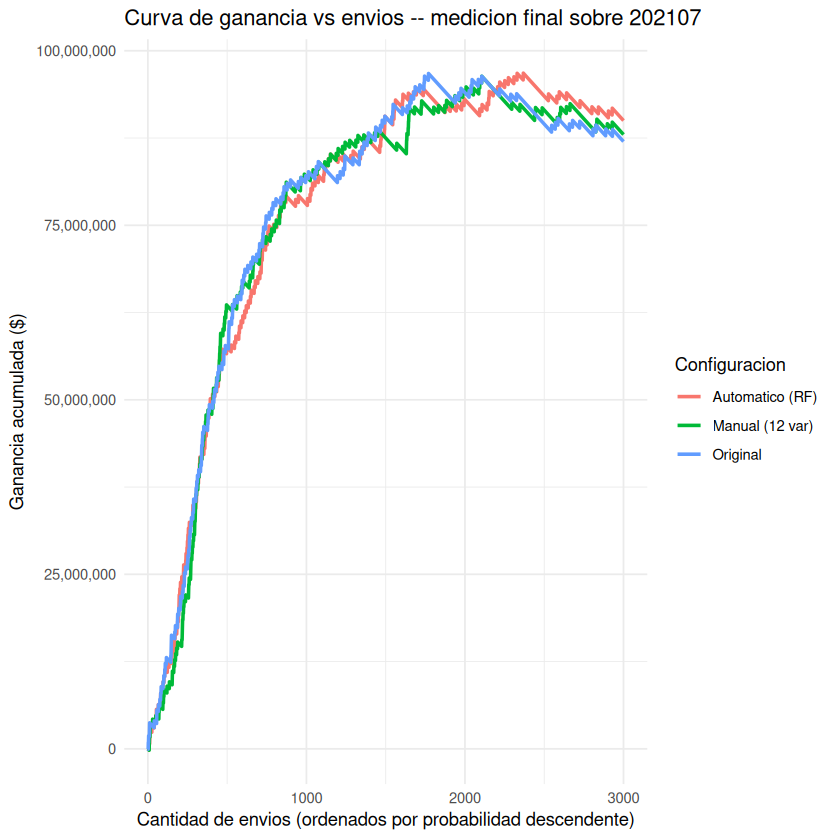

In [39]:
install.packages("ggplot2")
library(ggplot2)

ggplot(tb_curvas, aes(x = envios, y = ganancia, color = config)) +
  geom_line(linewidth = 1) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Curva de ganancia vs envios -- medicion final sobre 202107",
    x = "Cantidad de envios (ordenados por probabilidad descendente)",
    y = "Ganancia acumulada ($)",
    color = "Configuracion"
  ) +
  theme_minimal()